# Project 3: Hacker News Scraper

This notebook demonstrates scraping top articles from [Hacker News](https://news.ycombinator.com) in real time.

Hacker News のトップ記事をリアルタイムで取得し、データを分析するまでの過程を示します。

> **Note:** This notebook requires an internet connection. / インターネット接続が必要です。

---

In [1]:
%matplotlib inline
import sys
import logging
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, 'src')
from scraper import fetch_page, parse_articles, save_csv

print('Setup complete.')

Setup complete.


## 1. Fetch Top Articles / トップ記事を取得

Scrape the front page of Hacker News (~30 articles).

Hacker News のフロントページから記事一覧を取得します（約30件）。

In [2]:
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s', force=True)

soup = fetch_page('https://news.ycombinator.com')
articles = parse_articles(soup)

df = pd.DataFrame(articles)
print(f'\nFetched {len(df)} articles.')


Fetched 30 articles.


---
## 2. Results / 取得結果

All articles with title, URL, score, and timestamp.

In [3]:
logging.disable(logging.CRITICAL)
df

,title,url,score,scraped_at
0,Claude Code Unpacked : A visual guide,https://ccunpacked.dev/,449,2026-04-01 19:54:05
1,CERN levels up with new superconducting karts,https://home.cern/news/news/engineering/cern-l...,136,2026-04-01 19:54:05
2,Show HN: CLI to order groceries via reverse-en...,https://github.com/yannick-cw/korb,88,2026-04-01 19:54:05
3,Intuiting Pratt Parsing,https://louis.co.nz/2026/03/26/pratt-parsing.html,15,2026-04-01 19:54:05
4,Claude Wrote a Full FreeBSD Remote Kernel RCE ...,https://github.com/califio/publications/blob/m...,46,2026-04-01 19:54:05
5,What the Claude Code Leak Means for Regulated ...,https://systima.ai/blog/claude-code-leak-compl...,7,2026-04-01 19:54:05
6,A dot a day keeps the clutter away,https://scottlawsonbc.com/post/dot-system,339,2026-04-01 19:54:05
7,Bring Back MiniDV with This Raspberry Pi FireW...,https://www.jeffgeerling.com/blog/2026/minidv-...,68,2026-04-01 19:54:05
8,TinyLoRA – Learning to Reason in 13 Parameters,https://arxiv.org/abs/2602.04118,183,2026-04-01 19:54:05
9,"Show HN: 1-Bit Bonsai, the First Commercially ...",https://prismml.com/,275,2026-04-01 19:54:05


---
## 3. Keyword Filtering / キーワードフィルタ

Filter articles by keyword on the already-fetched data (no additional HTTP request).

取得済みデータをキーワードで絞り込みます（追加のHTTPリクエストなし）。

In [4]:
keyword = 'AI'

df_filtered = df[df['title'].str.contains(keyword, case=False, na=False)].reset_index(drop=True)
print(f'Articles containing "{keyword}": {len(df_filtered)}')
df_filtered[['title', 'score']]

Articles containing "AI": 4


,title,score
0,"Show HN: 1-Bit Bonsai, the First Commercially ...",275
1,OpenAI closes funding round at an $852B valuation,455
2,Why the US Navy won't blast the Iranians and '...,328
3,Back to FreeBSD – Part 2 – Jails,94


---
## 4. Score Analysis / スコア分析

Basic statistics and a chart of the top articles by score.

In [5]:
print('=== Score statistics ===')
print(df['score'].describe().apply(lambda x: f'{x:.1f}').to_string())

=== Score statistics ===
count      30.0
mean      257.4
std       375.2
min         7.0
25%        73.0
50%       143.5
75%       268.0
max      1850.0


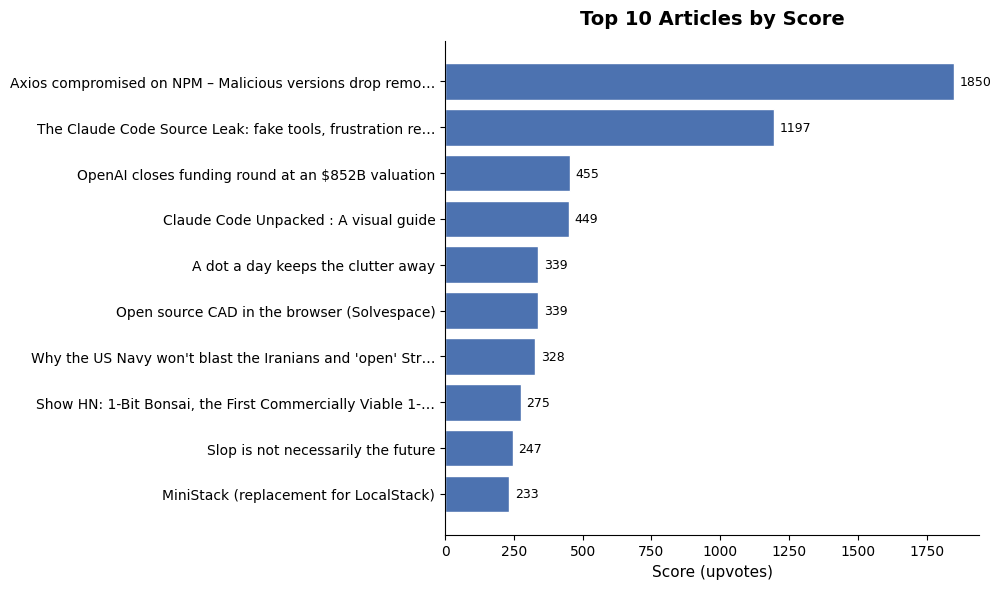

In [6]:
# Top 10 articles by score
top10 = df.nlargest(10, 'score')[['title', 'score']].reset_index(drop=True)

# Truncate long titles for display
top10['label'] = top10['title'].apply(lambda t: t[:55] + '…' if len(t) > 55 else t)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['label'][::-1], top10['score'][::-1], color='#4C72B0', edgecolor='white')
ax.bar_label(bars, labels=[str(v) for v in top10['score'][::-1]], padding=4, fontsize=9)
ax.set_title('Top 10 Articles by Score', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Score (upvotes)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 5. Save to CSV / CSV保存

In [7]:
logging.disable(logging.NOTSET)
save_csv(articles, 'output/hn_articles.csv')
print(f'Done. {len(articles)} articles saved to output/hn_articles.csv')

INFO: CSV出力完了: output/hn_articles.csv (30件)


Done. 30 articles saved to output/hn_articles.csv
